# E-Commerce Customer Lifetime Value (CLV) Prediction & Customer Segmentation

## Objective

The objective of this project is to analyze customer purchasing behavior, segment customers into meaningful groups using K-Means Clustering, and predict Customer Lifetime Value (CLV) using Machine Learning Regression models.

### Project Workflow

- Data Understanding
- Data Cleaning
- Exploratory Data Analysis
- Feature Engineering
- Customer Segmentation
- CLV Prediction
- Model Evaluation

In [2]:
# ================================
# Import Required Libraries
# ================================

import warnings
warnings.filterwarnings('ignore')

# Data Manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.preprocessing import StandardScaler

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

import joblib

In [3]:
# ================================
# Load Dataset
# ================================

df = pd.read_csv("online_retail_II.csv")

print("Dataset Loaded Successfully!")

Dataset Loaded Successfully!


In [4]:
df.shape

(1067371, 8)

In [5]:
df.head(10)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
5,489434,22064,PINK DOUGHNUT TRINKET POT,24,2009-12-01 07:45:00,1.65,13085.0,United Kingdom
6,489434,21871,SAVE THE PLANET MUG,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
7,489434,21523,FANCY FONT HOME SWEET HOME DOORMAT,10,2009-12-01 07:45:00,5.95,13085.0,United Kingdom
8,489435,22350,CAT BOWL,12,2009-12-01 07:46:00,2.55,13085.0,United Kingdom
9,489435,22349,"DOG BOWL , CHASING BALL DESIGN",12,2009-12-01 07:46:00,3.75,13085.0,United Kingdom


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  object 
 1   StockCode    1067371 non-null  object 
 2   Description  1062989 non-null  object 
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  object 
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 65.1+ MB


In [7]:
df.describe()

,Quantity,Price,Customer ID
count,1.067371e+06,1.067371e+06,824364.000000
mean,9.938898e+00,4.649388e+00,15324.638504
std,1.727058e+02,1.235531e+02,1697.464450
min,-8.099500e+04,-5.359436e+04,12346.000000
25%,1.000000e+00,1.250000e+00,13975.000000
50%,3.000000e+00,2.100000e+00,15255.000000
75%,1.000000e+01,4.150000e+00,16797.000000
max,8.099500e+04,3.897000e+04,18287.000000


In [8]:
df.isnull().sum()

,0
Invoice,0
StockCode,0
Description,4382
Quantity,0
InvoiceDate,0
Price,0
Customer ID,243007
Country,0


In [9]:
df.dtypes

,0
Invoice,object
StockCode,object
Description,object
Quantity,int64
InvoiceDate,object
Price,float64
Customer ID,float64
Country,object


In [10]:
# Missing Values

missing_values = df.isnull().sum()

missing_percentage = (
    df.isnull().sum() /
    len(df)
) * 100

missing_df = pd.DataFrame({
    "Missing Values": missing_values,
    "Percentage": missing_percentage
})

missing_df.sort_values(
    by="Percentage",
    ascending=False
)

,Missing Values,Percentage
Customer ID,243007,22.766873
Description,4382,0.410541
StockCode,0,0.000000
Invoice,0,0.000000
Quantity,0,0.000000
InvoiceDate,0,0.000000
Price,0,0.000000
Country,0,0.000000


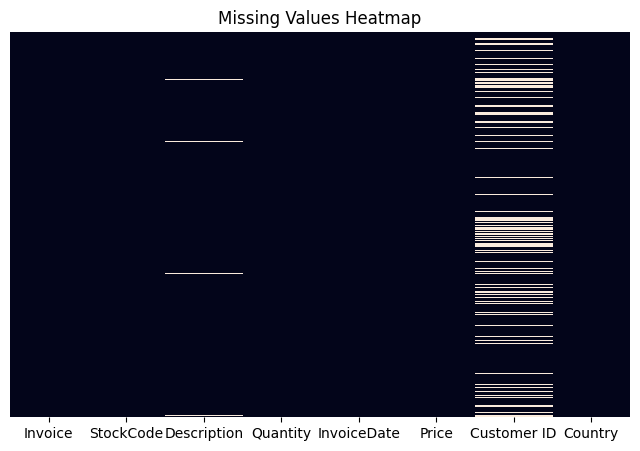

In [11]:
# Visualize Missing Values

plt.figure(figsize=(8,5))

sns.heatmap(
    df.isnull(),
    cbar=False,
    yticklabels=False
)

plt.title("Missing Values Heatmap")

plt.show()

In [12]:
# Duplicate Rows

duplicates = df.duplicated().sum()

print("Duplicate Rows:", duplicates)

Duplicate Rows: 34335


In [13]:
# Unique Values in Every Column

for col in df.columns:
    print(f"{col}: {df[col].nunique()}")

Invoice: 53628
StockCode: 5305
Description: 5698
Quantity: 1057
InvoiceDate: 47635
Price: 2807
Customer ID: 5942
Country: 43


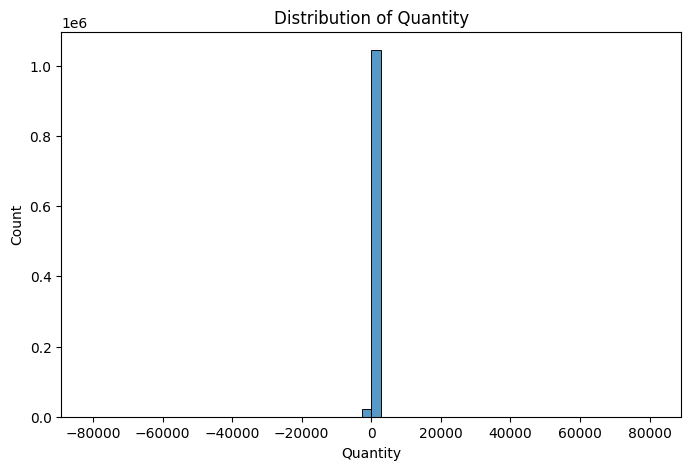

In [14]:
# Distribution of Quantity

plt.figure(figsize=(8,5))

sns.histplot(df["Quantity"], bins=60)

plt.title("Distribution of Quantity")

plt.show()

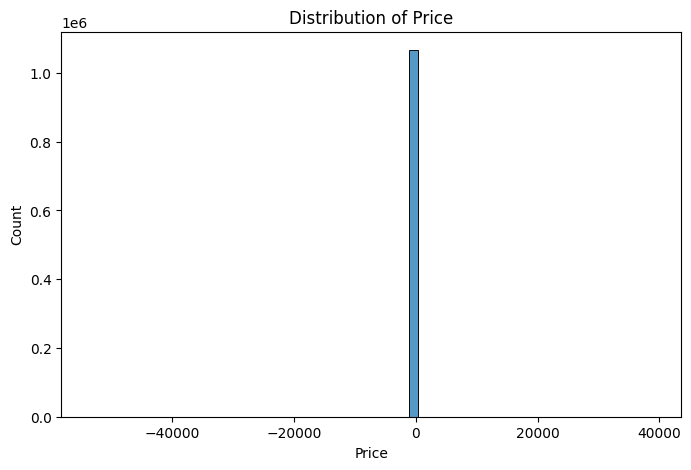

In [15]:
# Distribution of Price

plt.figure(figsize=(8,5))

sns.histplot(df["Price"], bins=60)

plt.title("Distribution of Price")

plt.show()

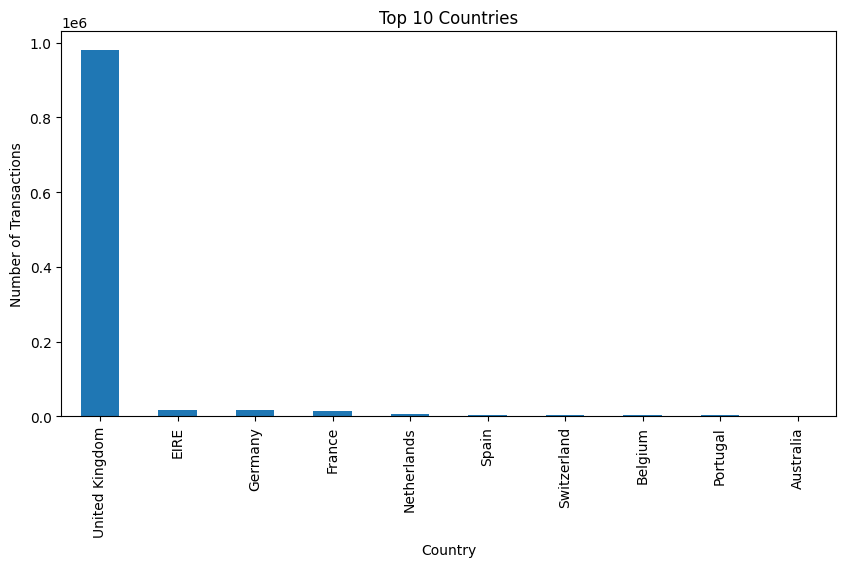

In [16]:
# Top 10 Countries

plt.figure(figsize=(10,5))

df["Country"].value_counts().head(10).plot(kind="bar")

plt.title("Top 10 Countries")

plt.ylabel("Number of Transactions")

plt.show()

# Data Cleaning

The raw dataset contains missing values, cancelled transactions, returns, duplicate records and invalid values. These issues need to be handled before feature engineering and model building.

In [17]:
# Convert InvoiceDate to datetime

df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

In [18]:
df.dtypes

,0
Invoice,object
StockCode,object
Description,object
Quantity,int64
InvoiceDate,datetime64[ns]
Price,float64
Customer ID,float64
Country,object


In [19]:
print("Before:", df.shape)

df1 = df.dropna(subset=["Customer ID"])

print("After:", df1.shape)

Before: (1067371, 8)
After: (824364, 8)


In [20]:
df1 = df1.dropna(subset=["Description"])

In [21]:
print("Duplicate Rows:", df1.duplicated().sum())

df1 = df1.drop_duplicates()

print("Dataset Shape:", df1.shape)

Duplicate Rows: 26479
Dataset Shape: (797885, 8)


In [22]:
# Remove cancelled invoices

df1 = df1[~df1["Invoice"].astype(str).str.startswith("C")]

In [23]:
#remove negative quantities
df1 = df1[df1["Quantity"] > 0]

In [24]:
#remove invalid prices
df1 = df1[df1["Price"] > 0]

In [25]:
print(df1.shape)

df1.head(10)

(779425, 8)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
5,489434,22064,PINK DOUGHNUT TRINKET POT,24,2009-12-01 07:45:00,1.65,13085.0,United Kingdom
6,489434,21871,SAVE THE PLANET MUG,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
7,489434,21523,FANCY FONT HOME SWEET HOME DOORMAT,10,2009-12-01 07:45:00,5.95,13085.0,United Kingdom
8,489435,22350,CAT BOWL,12,2009-12-01 07:46:00,2.55,13085.0,United Kingdom
9,489435,22349,"DOG BOWL , CHASING BALL DESIGN",12,2009-12-01 07:46:00,3.75,13085.0,United Kingdom


In [26]:
#verify cleaning
print(df1.isnull().sum())

Invoice        0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
Price          0
Customer ID    0
Country        0
dtype: int64


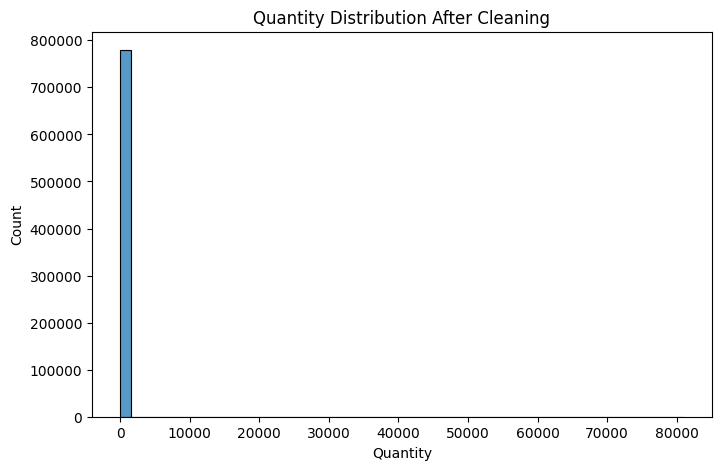

In [27]:
plt.figure(figsize=(8,5))
sns.histplot(df1["Quantity"], bins=50)
plt.title("Quantity Distribution After Cleaning")
plt.show()

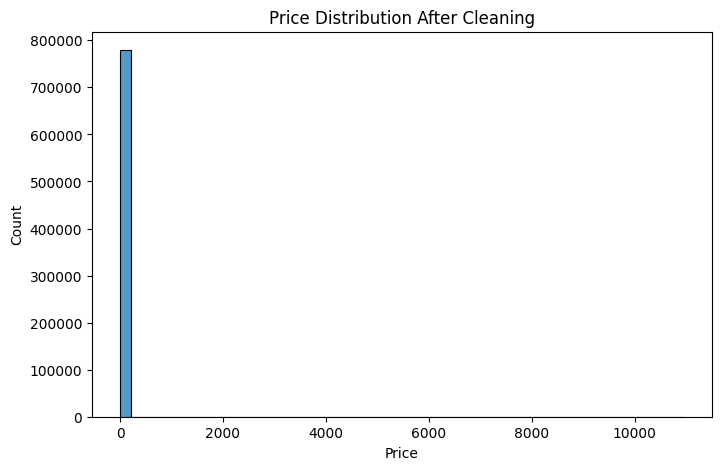

In [28]:
plt.figure(figsize=(8,5))
sns.histplot(df1["Price"], bins=50)
plt.title("Price Distribution After Cleaning")
plt.show()

In [29]:
print("="*40)
print("Final Dataset Shape :", df1.shape)
print("Missing Values      :", df1.isnull().sum().sum())
print("Duplicate Rows      :", df1.duplicated().sum())
print("Date Range          :", df1["InvoiceDate"].min(), "to", df1["InvoiceDate"].max())
print("="*40)

Final Dataset Shape : (779425, 8)
Missing Values      : 0
Duplicate Rows      : 0
Date Range          : 2009-12-01 07:45:00 to 2011-12-09 12:50:00


# Feature Engineering (RFM Analysis)

To understand customer purchasing behavior, we create RFM (Recency, Frequency, Monetary) features.

- **Recency:** Number of days since the customer's last purchase.
- **Frequency:** Number of unique purchases made by the customer.
- **Monetary:** Total amount spent by the customer.

These features are widely used for customer segmentation and Customer Lifetime Value (CLV) prediction.

In [30]:
# ======================================
# Create Total Price
# ======================================

df1["TotalPrice"] = df1["Quantity"] * df1["Price"]

df1.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalPrice
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


In [31]:
# ======================================
# Reference Date
# ======================================

snapshot_date = df1["InvoiceDate"].max() + pd.Timedelta(days=1)    #Adding one day ensures that the most recent customer has a recency of 1 day, not 0.

print("Snapshot Date:", snapshot_date)

Snapshot Date: 2011-12-10 12:50:00


In [32]:
# ======================================
# Create RFM Features
# ======================================

rfm = df1.groupby("Customer ID").agg({

    "InvoiceDate": lambda x: (snapshot_date - x.max()).days,

    "Invoice": "nunique",

    "TotalPrice": "sum"

})

rfm.columns = ["Recency", "Frequency", "Monetary"]

rfm.head()

,Recency,Frequency,Monetary
Customer ID,,,
12346.0,326,12,77556.46
12347.0,2,8,4921.53
12348.0,75,5,2019.40
12349.0,19,4,4428.69
12350.0,310,1,334.40


In [33]:
print("Number of Customers:", rfm.shape[0])

rfm.head()

Number of Customers: 5878


,Recency,Frequency,Monetary
Customer ID,,,
12346.0,326,12,77556.46
12347.0,2,8,4921.53
12348.0,75,5,2019.40
12349.0,19,4,4428.69
12350.0,310,1,334.40


In [34]:
rfm.describe()

,Recency,Frequency,Monetary
count,5878.000000,5878.000000,5878.000000
mean,201.331916,6.289384,2955.904095
std,209.338707,13.009406,14440.852688
min,1.000000,1.000000,2.950000
25%,26.000000,1.000000,342.280000
50%,96.000000,3.000000,867.740000
75%,380.000000,7.000000,2248.305000
max,739.000000,398.000000,580987.040000


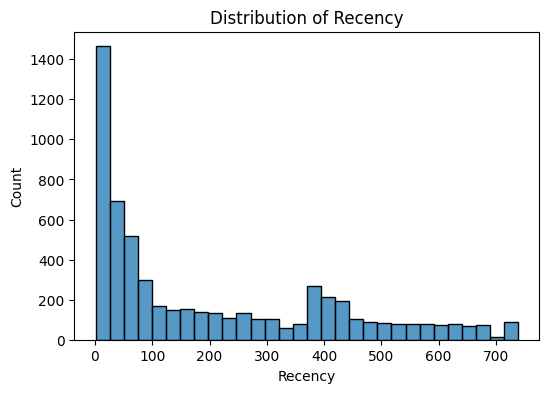

In [35]:
plt.figure(figsize=(6,4))
sns.histplot(rfm["Recency"], bins=30)
plt.title("Distribution of Recency")
plt.show()

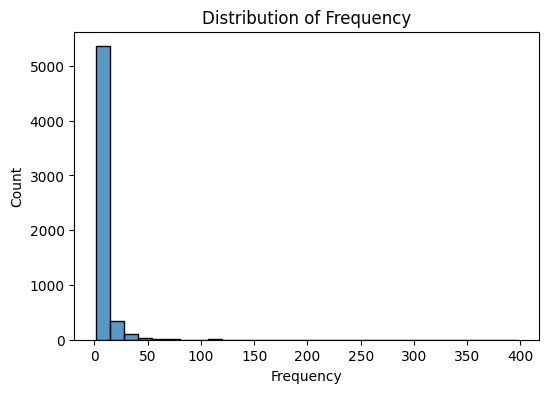

In [36]:
plt.figure(figsize=(6,4))
sns.histplot(rfm["Frequency"], bins=30)
plt.title("Distribution of Frequency")
plt.show()

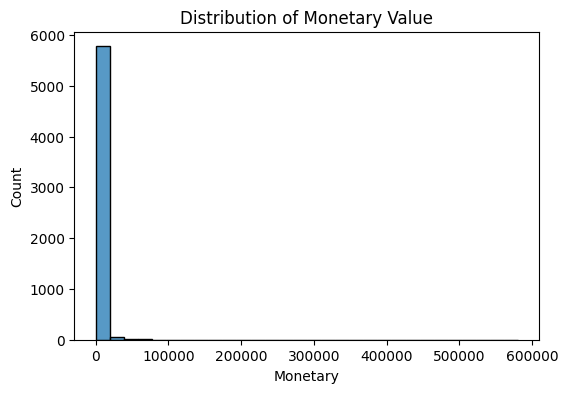

In [37]:
plt.figure(figsize=(6,4))
sns.histplot(rfm["Monetary"], bins=30)
plt.title("Distribution of Monetary Value")
plt.show()

In [38]:
# ======================================
# Average Order Value
# ======================================

aov = df1.groupby("Customer ID")["TotalPrice"].mean()

rfm["AverageOrderValue"] = aov

In [39]:
# ======================================
# Customer Tenure
# ======================================

tenure = df1.groupby("Customer ID")["InvoiceDate"].agg(
    lambda x: (x.max() - x.min()).days
)

rfm["CustomerTenure"] = tenure

In [40]:
# ======================================
# Purchase Frequency
# ======================================

rfm["PurchaseFrequency"] = (
    rfm["Frequency"] /
    (rfm["CustomerTenure"] + 1)
)

In [41]:
rfm.head()

,Recency,Frequency,Monetary,AverageOrderValue,CustomerTenure,PurchaseFrequency
Customer ID,,,,,,
12346.0,326,12,77556.46,2281.072353,400,0.029925
12347.0,2,8,4921.53,22.169054,402,0.019851
12348.0,75,5,2019.40,39.596078,362,0.013774
12349.0,19,4,4428.69,25.306800,570,0.007005
12350.0,310,1,334.40,19.670588,0,1.000000


In [42]:
rfm.describe().T

,count,mean,std,min,25%,50%,75%,max
Recency,5878.0,201.331916,209.338707,1.000000,26.000000,96.000000,380.0000,739.00
Frequency,5878.0,6.289384,13.009406,1.000000,1.000000,3.000000,7.0000,398.00
Monetary,5878.0,2955.904095,14440.852688,2.950000,342.280000,867.740000,2248.3050,580987.04
AverageOrderValue,5878.0,48.301822,780.176769,2.135778,11.564180,17.367639,24.1819,56157.50
CustomerTenure,5878.0,273.022457,258.807591,0.000000,0.000000,220.500000,511.0000,738.00
PurchaseFrequency,5878.0,0.327004,0.490198,0.002797,0.013072,0.027159,1.0000,6.00


In [43]:
rfm.to_csv("rfm_features.csv")

# Customer Segmentation using K-Means Clustering

Customer segmentation helps identify groups of customers with similar purchasing behavior based on RFM (Recency, Frequency, Monetary) features.

The RFM features are first standardized to ensure all variables contribute equally during clustering. The optimal number of clusters is determined using the Elbow Method and validated using the Silhouette Score.

In [44]:
# ======================================
# Select Features for Clustering
# ======================================

rfm_features = rfm[['Recency', 'Frequency', 'Monetary']]

rfm_features.head()

,Recency,Frequency,Monetary
Customer ID,,,
12346.0,326,12,77556.46
12347.0,2,8,4921.53
12348.0,75,5,2019.40
12349.0,19,4,4428.69
12350.0,310,1,334.40


In [45]:
# ======================================
# Standardize Features
# ======================================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm_features)

print(rfm_scaled.shape)

(5878, 3)


In [46]:
# ======================================
# Elbow Method
# ======================================

inertia = []

K = range(2,11)

for k in K:
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(rfm_scaled)

    inertia.append(model.inertia_)

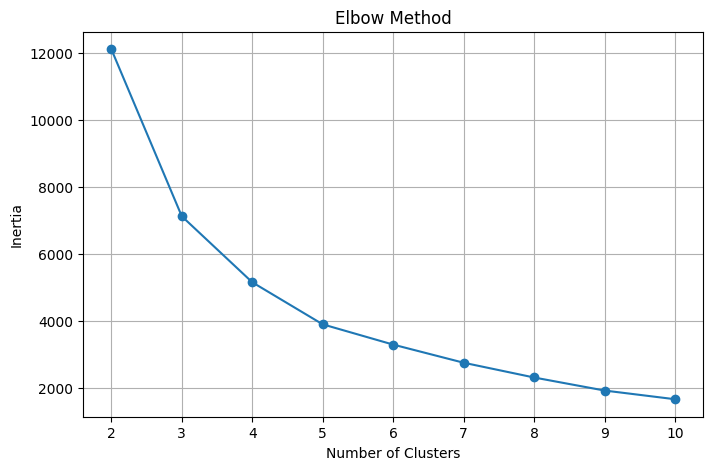

In [47]:
plt.figure(figsize=(8,5))

plt.plot(K, inertia, marker='o')

plt.xlabel("Number of Clusters")

plt.ylabel("Inertia")

plt.title("Elbow Method")

plt.grid(True)

plt.show()

In [48]:
# ======================================
# Silhouette Score for Different K
# ======================================

from sklearn.metrics import silhouette_score

scores = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(rfm_scaled)

    score = silhouette_score(rfm_scaled, labels)

    scores.append(score)

    print(f"K = {k} --> Silhouette Score = {score:.4f}")

K = 2 --> Silhouette Score = 0.9236
K = 3 --> Silhouette Score = 0.5827
K = 4 --> Silhouette Score = 0.5913
K = 5 --> Silhouette Score = 0.6030
K = 6 --> Silhouette Score = 0.5495
K = 7 --> Silhouette Score = 0.5493
K = 8 --> Silhouette Score = 0.5506
K = 9 --> Silhouette Score = 0.5414
K = 10 --> Silhouette Score = 0.5034


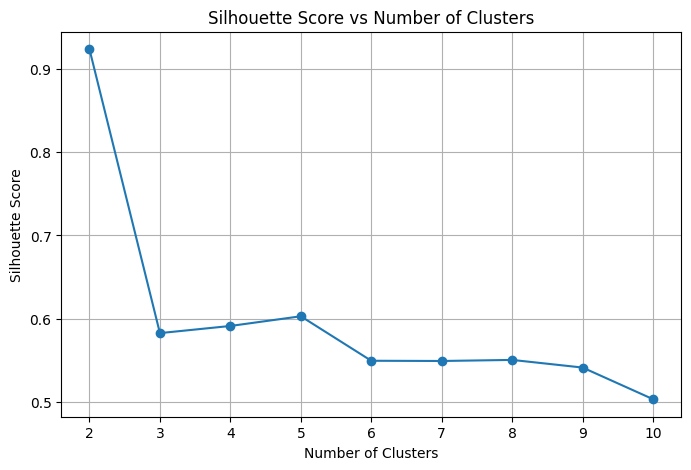

In [49]:
plt.figure(figsize=(8,5))

plt.plot(range(2,11), scores, marker='o')

plt.xlabel("Number of Clusters")

plt.ylabel("Silhouette Score")

plt.title("Silhouette Score vs Number of Clusters")

plt.grid(True)

plt.show()

Select K=5 for K Means Clustering as its silhouette score is the highest(0.603)

In [50]:
# ======================================
# Train Final KMeans Model
# ======================================

kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

rfm["Cluster"] = kmeans.fit_predict(rfm_scaled)

print("Silhouette Score:", round(silhouette_score(rfm_scaled, rfm["Cluster"]), 3))

Silhouette Score: 0.603


In [51]:
cluster_summary = rfm.groupby("Cluster").agg({
    "Recency": "mean",
    "Frequency": "mean",
    "Monetary": "mean",
    "AverageOrderValue": "mean",
    "CustomerTenure": "mean",
    "PurchaseFrequency": "mean"
}).round(2)

cluster_summary

,Recency,Frequency,Monetary,AverageOrderValue,CustomerTenure,PurchaseFrequency
Cluster,,,,,,
0,75.27,5.23,1920.56,33.41,337.12,0.21
1,470.70,2.16,737.17,45.01,78.65,0.61
2,3.50,212.50,428612.00,199.98,734.50,0.29
3,22.46,119.79,98956.85,2486.07,667.00,0.18
4,25.78,29.47,14171.55,49.52,650.19,0.05


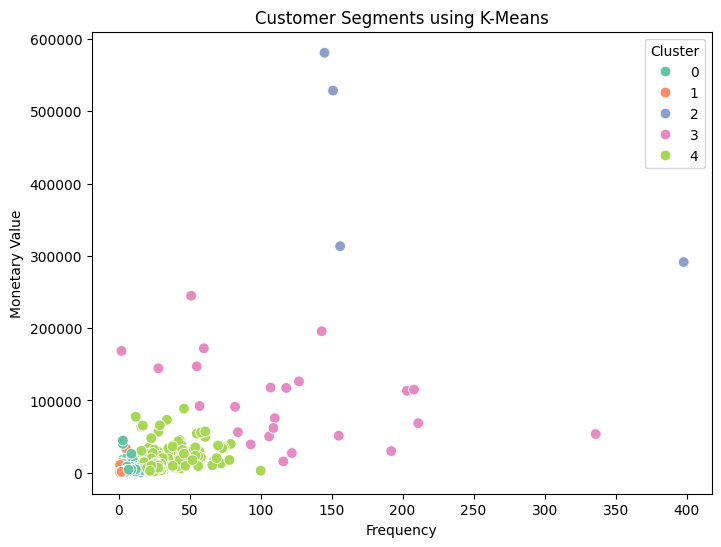

In [52]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=rfm,
    x="Frequency",
    y="Monetary",
    hue="Cluster",
    palette="Set2",
    s=60
)

plt.title("Customer Segments using K-Means")
plt.xlabel("Frequency")
plt.ylabel("Monetary Value")

plt.show()

In [53]:
# ======================================
# Assign Business Labels to Clusters
# ======================================

cluster_names = {
    0: "Regular Customers",
    1: "At-Risk Customers",
    2: "VIP Customers",
    3: "Premium Customers",
    4: "Loyal Customers"
}

rfm["CustomerSegment"] = rfm["Cluster"].map(cluster_names)

rfm.head()

,Recency,Frequency,Monetary,AverageOrderValue,CustomerTenure,PurchaseFrequency,Cluster,CustomerSegment
Customer ID,,,,,,,,
12346.0,326,12,77556.46,2281.072353,400,0.029925,4,Loyal Customers
12347.0,2,8,4921.53,22.169054,402,0.019851,0,Regular Customers
12348.0,75,5,2019.40,39.596078,362,0.013774,0,Regular Customers
12349.0,19,4,4428.69,25.306800,570,0.007005,0,Regular Customers
12350.0,310,1,334.40,19.670588,0,1.000000,1,At-Risk Customers


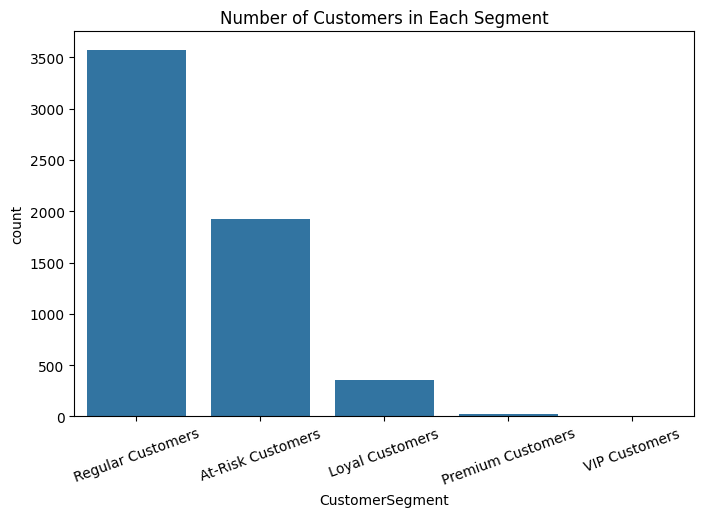

In [54]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=rfm,
    x="CustomerSegment",
    order=rfm["CustomerSegment"].value_counts().index
)

plt.xticks(rotation=20)
plt.title("Number of Customers in Each Segment")

plt.show()

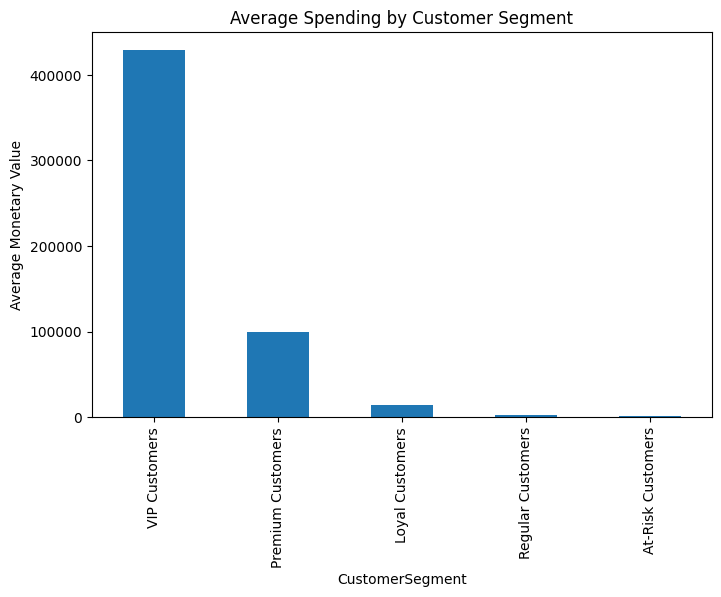

In [55]:
plt.figure(figsize=(8,5))

segment_revenue = (
    rfm.groupby("CustomerSegment")["Monetary"]
       .mean()
       .sort_values(ascending=False)
)

segment_revenue.plot(kind="bar")

plt.ylabel("Average Monetary Value")
plt.title("Average Spending by Customer Segment")

plt.show()

In [56]:
joblib.dump(kmeans, "kmeans_model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [57]:
# ======================================
# Prepare Data for Regression
# ======================================

X = rfm[[
    "Recency",
    "Frequency",
    "CustomerTenure",
    "PurchaseFrequency"
]]

y = rfm["Monetary"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (5878, 4)
Target Shape: (5878,)


In [58]:
# ======================================
# Train Test Split
# ======================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [59]:
# ======================================
# Linear Regression
# ======================================

lr = LinearRegression()

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

In [60]:
# ======================================
# Random Forest Regression
# ======================================

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [61]:
# ======================================
# Model Evaluation
# ======================================

def evaluate_model(name, y_true, y_pred):

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    mae = mean_absolute_error(y_true, y_pred)

    r2 = r2_score(y_true, y_pred)

    mape = np.mean(
        np.abs((y_true - y_pred) / y_true)
    ) * 100

    print(f"\n{name}")
    print("-" * 30)
    print("RMSE :", round(rmse,2))
    print("MAE  :", round(mae,2))
    print("R²   :", round(r2,3))
    print("MAPE :", round(mape,2))

In [62]:
evaluate_model(
    "Linear Regression",
    y_test,
    lr_pred
)

evaluate_model(
    "Random Forest",
    y_test,
    rf_pred
)


Linear Regression
------------------------------
RMSE : 14796.45
MAE  : 1935.8
R²   : 0.397
MAPE : 138.27

Random Forest
------------------------------
RMSE : 15033.51
MAE  : 2114.0
R²   : 0.378
MAPE : 177.19


In [63]:
joblib.dump(lr, "clv_model.pkl")

['clv_model.pkl']

In [64]:
rfm.to_csv("rfm_final.csv", index=True)